In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
path= 'train.csv'
data= pd.read_csv(path)
df= data.copy()

### EDA

In [4]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
df.shape

(913000, 4)

In [6]:
df.isna()

,date,store,item,sales
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
912995,False,False,False,False
912996,False,False,False,False
912997,False,False,False,False
912998,False,False,False,False


In [7]:
df.index

RangeIndex(start=0, stop=913000, step=1)

In [8]:
df.dtypes

date     object
store     int64
item      int64
sales     int64
dtype: object

In [9]:
df['date']= pd.DatetimeIndex(df['date'])

In [10]:
from IPython.display import display, HTML

cols = ['store', 'item']
html_str = "<div style='display: flex; gap: 20px;'>"

for col in cols:
    # .sort_index() organizes the labels numerically or alphabetically
    table_html = df[col].value_counts().sort_index().to_frame().to_html()
    html_str += f"<div><h3>{col}</h3>{table_html}</div>"

html_str += "</div>"
display(HTML(html_str))

,count
store,
1,91300
2,91300
3,91300
4,91300
5,91300
6,91300
7,91300
8,91300
9,91300


In [11]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [12]:
# check for every single day, that store x holds a record of sales for all of its items .
c= df.groupby(['date','store'])['item'].count()
print('nb of observations of items per store at any given day:',c.mean())

nb of observations of items per store at any given day: 50.0


**Investigating any missing days records**

In [13]:
expected_dates = pd.date_range(start='2013-01-01', end='2017-12-31')
# Compare unique dates in your data to the reference
missing_dates = expected_dates.difference(df['date'].unique())
print(f"Number of missing days: {len(missing_dates)}")

Number of missing days: 0


In [14]:
df =df.set_index('date')
df.head(3)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14


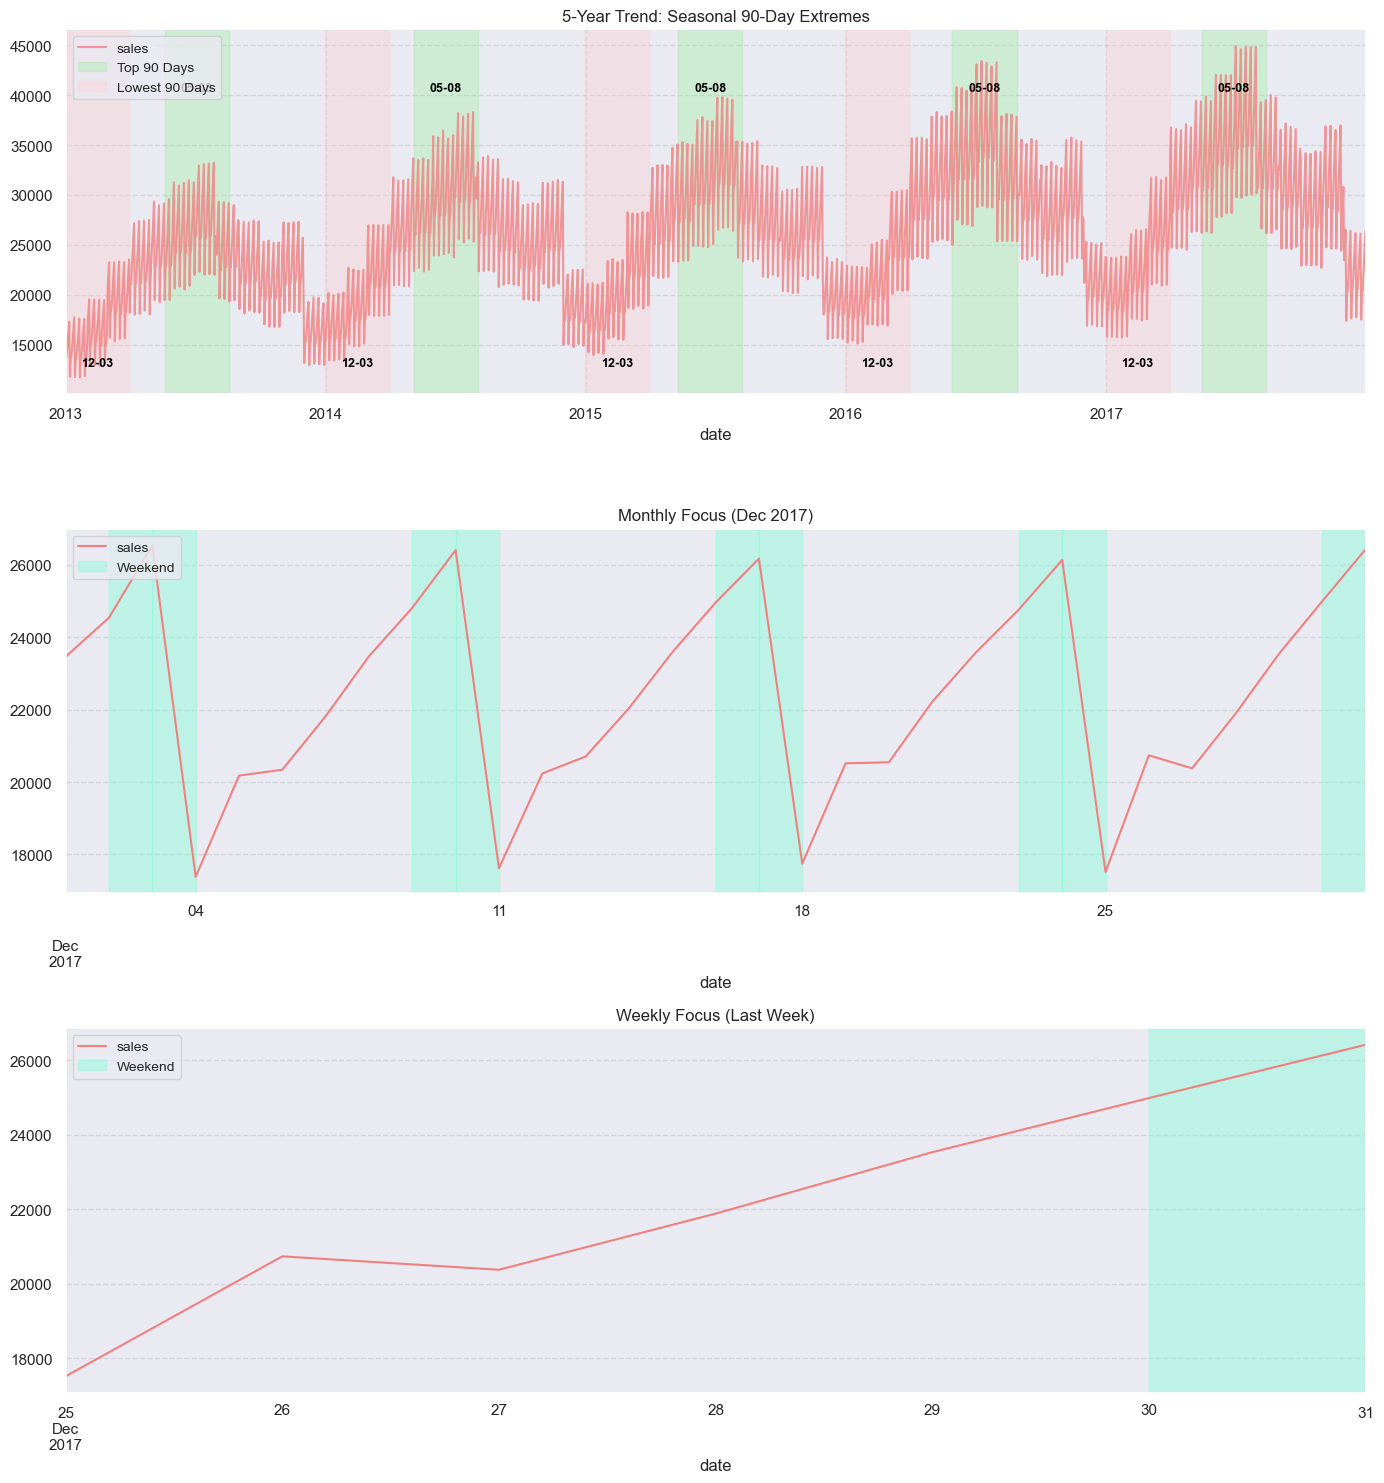

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Aggregate daily sales
daily_sales = df['sales'].resample('D').sum()

# 2. Setup Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 15))
red_milk = '#F08080'
gray_cool = '#808080'
aqua_highlight = '#7FFFD4'
low_red = '#FFCCCB'    
high_green = '#90EE90' 

# --- Graph 1: 5-Year Trend with Peak/Low Windows & Text ---
daily_sales.plot(ax=axes[0], color=red_milk, title='5-Year Trend: Seasonal 90-Day Extremes', alpha=0.8)

for year in range(2013, 2018):
    year_data = daily_sales[str(year)]
    rolling_90 = year_data.rolling(window=90).sum()
    
    # End dates and start dates
    peak_end, low_end = rolling_90.idxmax(), rolling_90.idxmin()
    peak_start, low_start = peak_end - pd.Timedelta(days=90), low_end - pd.Timedelta(days=90)
    
    # Text labels (MM - MM)
    peak_label = f"{peak_start.strftime('%m')}-{peak_end.strftime('%m')}"
    low_label = f"{low_start.strftime('%m')}-{low_end.strftime('%m')}"
    
    # Highs
    axes[0].axvspan(peak_start, peak_end, color=high_green, alpha=0.3, label='Top 90 Days' if year == 2013 else "")
    axes[0].text(peak_start + (peak_end - peak_start)/2, daily_sales.max()*0.9, peak_label, 
                 color='black', weight='bold', ha='center', fontsize=9)
    
    # Lows
    axes[0].axvspan(low_start, low_end, color=low_red, alpha=0.3, label='Lowest 90 Days' if year == 2013 else "")
    axes[0].text(low_start + (low_end - low_start)/2, daily_sales.min()*1.1, low_label, 
                 color='black', weight='bold', ha='center', fontsize=9)

# --- Graph 2: December 2017 & Weekends ---
dec_sales = daily_sales['2017-12']
dec_sales.plot(ax=axes[1], color=red_milk, title='Monthly Focus (Dec 2017)')
weekends = dec_sales.index[dec_sales.index.weekday >= 5]
for i, day in enumerate(weekends):
    axes[1].axvspan(day, day + pd.Timedelta(days=1), color=aqua_highlight, alpha=0.4, label='Weekend' if i == 0 else "")

# --- Graph 3: Last Week & Weekends ---
last_week_sales = daily_sales['2017-12-25':]
last_week_sales.plot(ax=axes[2], color=red_milk, title='Weekly Focus (Last Week)')
lw_weekends = last_week_sales.index[last_week_sales.index.weekday >= 5]
for i, day in enumerate(lw_weekends):
    axes[2].axvspan(day, day + pd.Timedelta(days=1), color=aqua_highlight, alpha=0.4, label='Weekend' if i == 0 else "")

# Global Formatting
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.2, color=gray_cool)
    ax.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

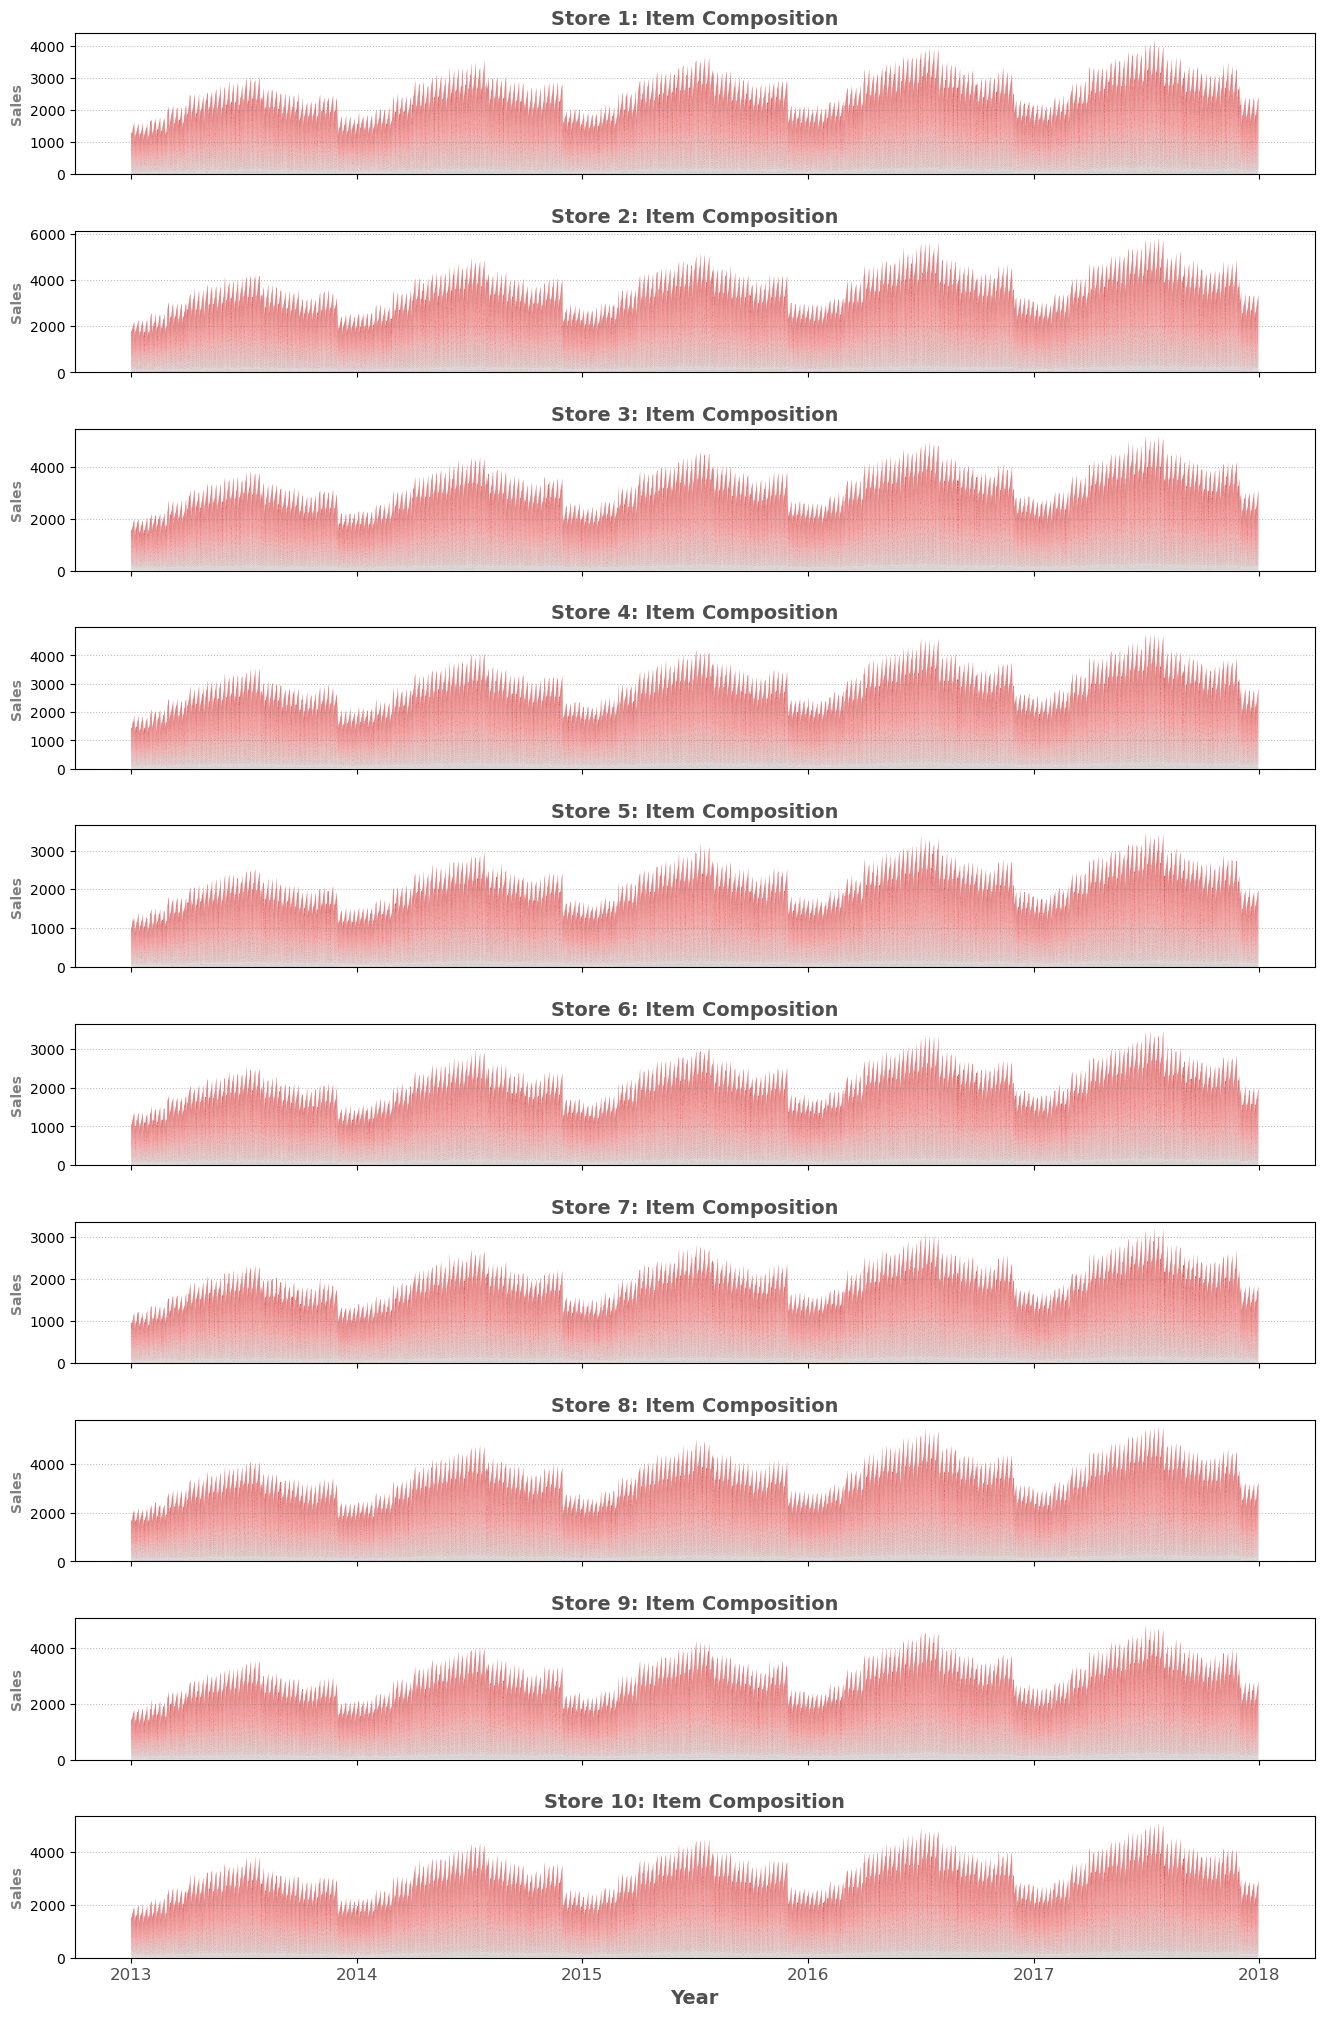

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Force a clean white background
plt.style.use('default') 

# 2. Create a sharper Gradient
# Using a darker Red ('#D64545') to ensure visibility against white
colors = mcolors.LinearSegmentedColormap.from_list("custom_grad", ['#D3D3D3', '#F08080', '#D64545'])
item_colors = [colors(i/50) for i in range(50)]

# 3. Setup Figure
fig, axes = plt.subplots(10, 1, figsize=(16, 25), sharex=True, facecolor='white')
plt.subplots_adjust(hspace=0.4)

for store_id in range(1, 11):
    ax = axes[store_id - 1]
    ax.set_facecolor('white') # Ensure subplot background is white
    
    # Pivot data
    store_df = df[df['store'] == store_id].pivot(columns='item', values='sales')
    
    # Plot using stackplot - Removing 'edgecolor' prevents the "gray haze"
    ax.stackplot(store_df.index, store_df.values.T, 
                 colors=item_colors, 
                 alpha=1.0, 
                 edgecolor='none') 
    
    # Formatting
    ax.set_title(f'Store {store_id}: Item Composition', color='#4F4F4F', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sales', color='#808080', fontweight='bold')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray')

# 4. Handle X-Axis (Yearly Ticks)
years = pd.date_range(start='2013-01-01', end='2018-01-01', freq='YS')
axes[-1].set_xticks(years)
axes[-1].set_xticklabels([date.year for date in years], color='#4F4F4F', fontsize=12)
axes[-1].set_xlabel('Year', fontsize=14, color='#4F4F4F', fontweight='bold')

plt.show()

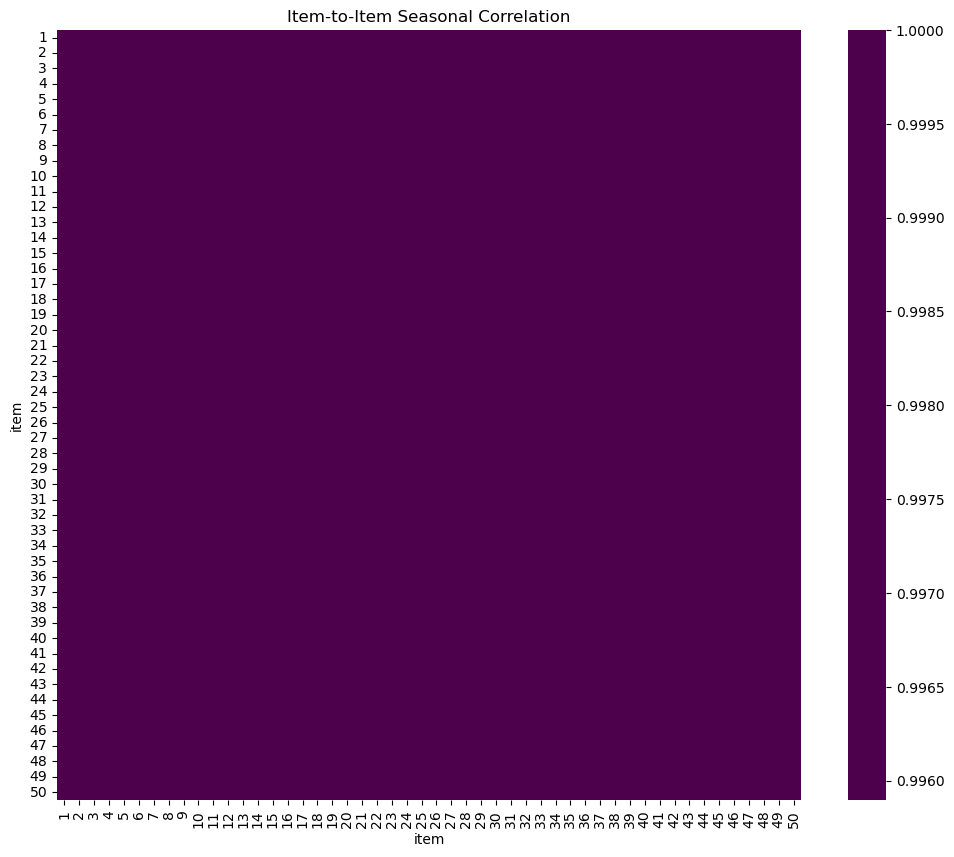

In [17]:
# 1. Pivot: Columns = Items, Rows = Months, Values = Sum of Sales
item_monthly_sales = df.pivot_table(index=df.index.to_period('M'), 
                                    columns='item', 
                                    values='sales', 
                                    aggfunc='sum')

# 2. Compute the Correlation Matrix
item_corr = item_monthly_sales.corr()

# 3. Plotting the Heatmap
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(item_corr, cmap='BuPu', center=0)
plt.title("Item-to-Item Seasonal Correlation")
plt.show()

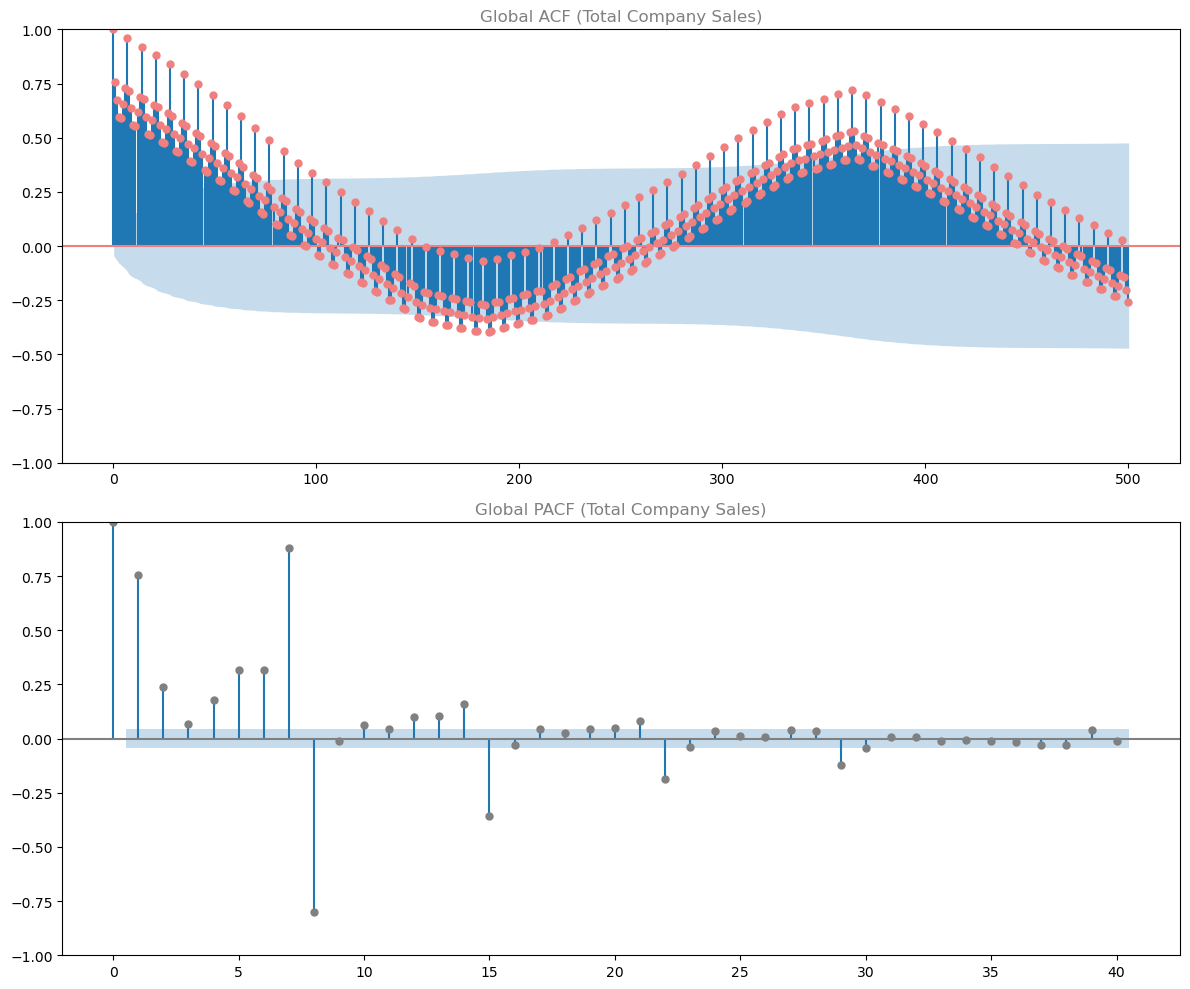

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Aggregate to company level
company_sales = df['sales'].resample('D').sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF: Shows the "seasonal" cycles (Look for spikes at 7, 14, 21...)
plot_acf(company_sales, lags=500, ax=ax1, color='#F08080')
ax1.set_title('Global ACF (Total Company Sales)', color='#808080')

# PACF: Shows which specific lags are truly unique/predictive
plot_pacf(company_sales, lags=40, ax=ax2, color='#808080')
ax2.set_title('Global PACF (Total Company Sales)', color='#808080')

plt.tight_layout()
plt.show()

**Conclusion:**
+ pacf: 1, 2, 7, 8 lagged features.
+ acf: 7 rolling (mean/std), 365 rolling mean

### is_holyday feature

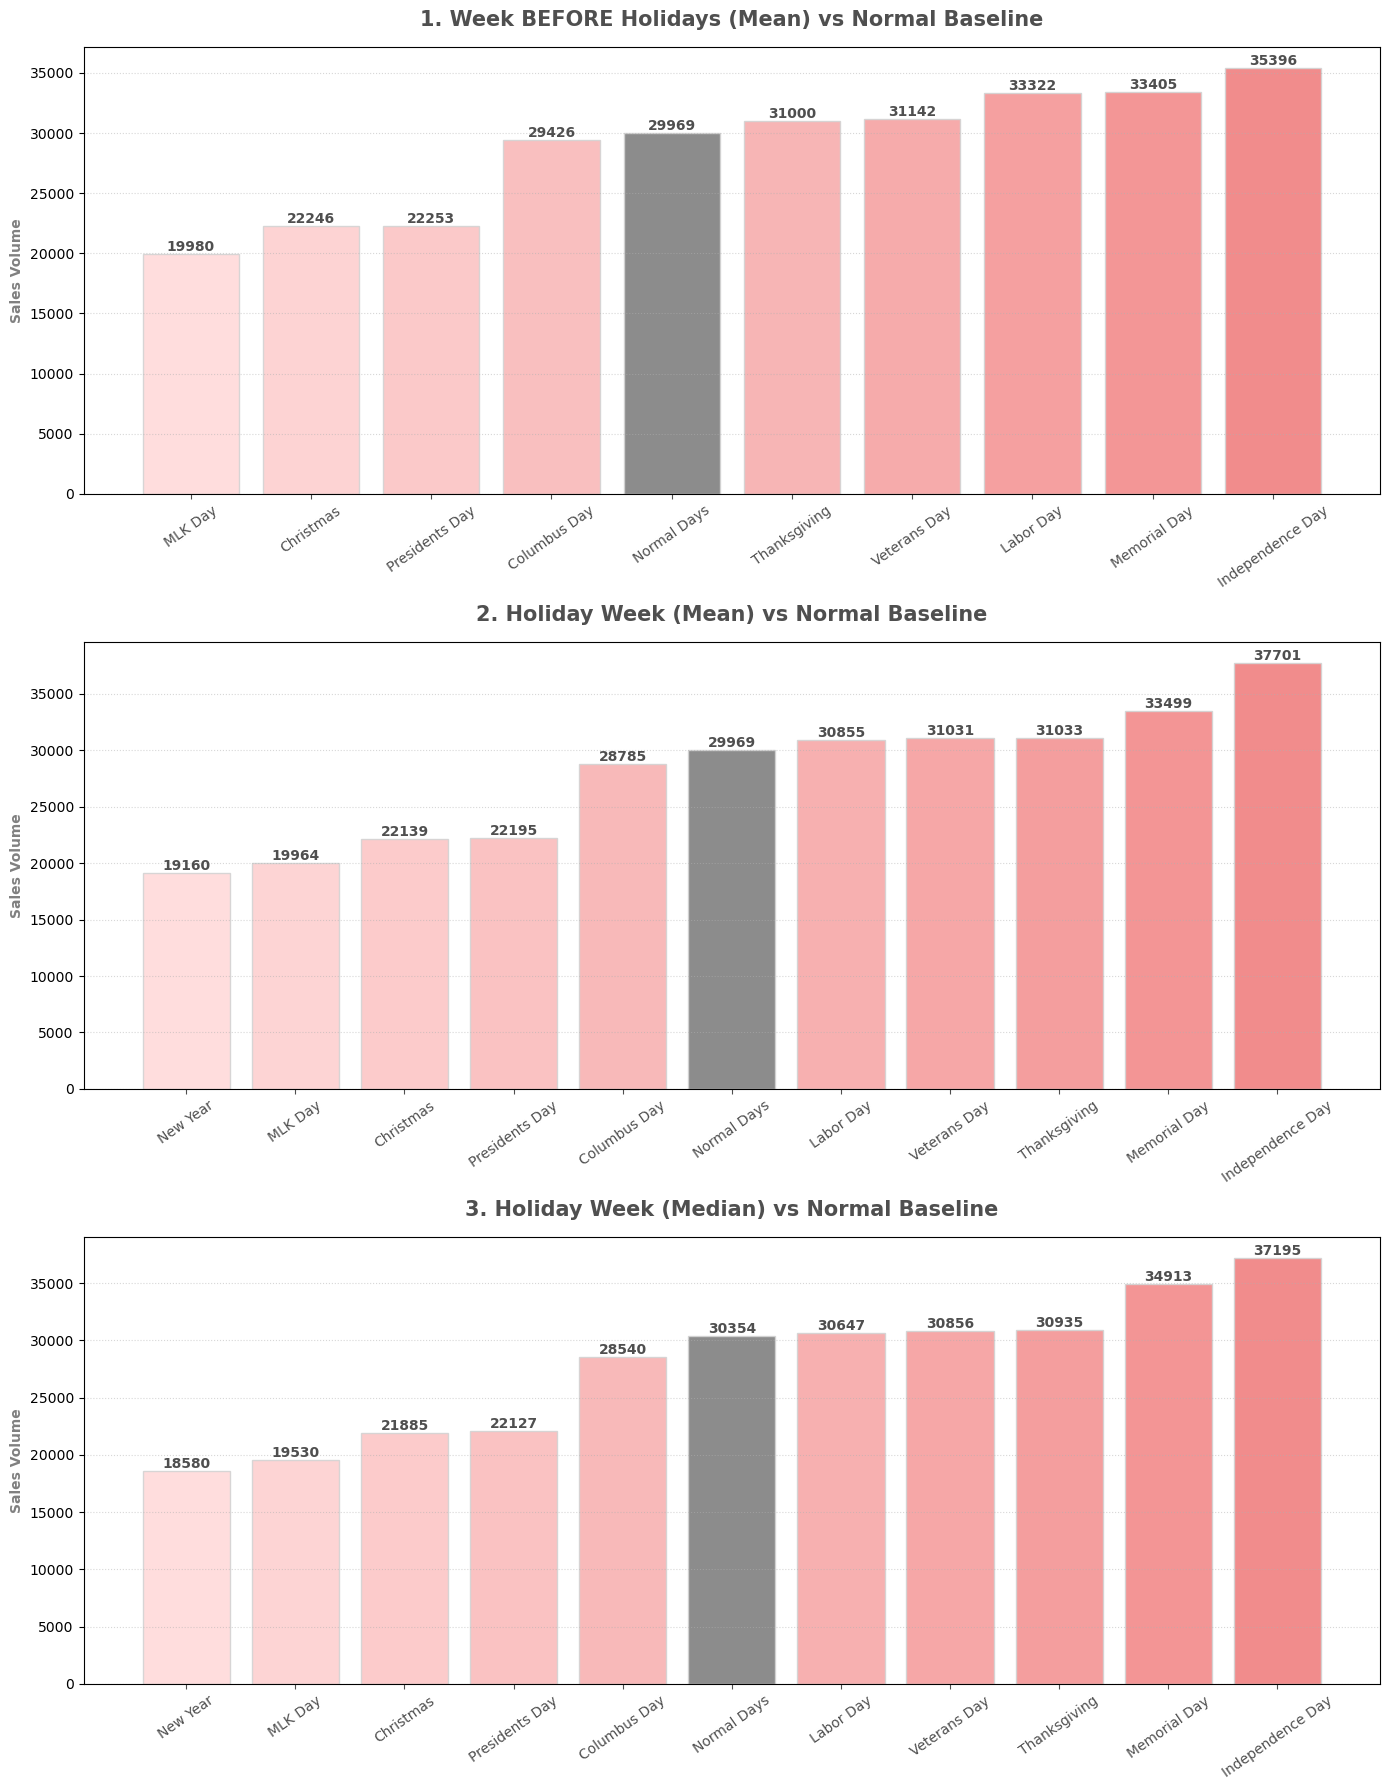

In [19]:
# 1. Aggregate daily sales and slice 2017
daily_sales = df['sales'].resample('D').sum()
df_2017 = daily_sales['2017']

# 2. Define Holidays and Time Windows
holidays_2017 = {
    'New Year': '2017-01-01', 'MLK Day': '2017-01-16', 'Presidents Day': '2017-02-20',
    'Memorial Day': '2017-05-29', 'Independence Day': '2017-07-04', 'Labor Day': '2017-09-04',
    'Columbus Day': '2017-10-09', 'Veterans Day': '2017-11-11', 'Thanksgiving': '2017-11-23',
    'Christmas': '2017-12-25'
}

h_windows, p_windows, excluded = {}, {}, []
for name, d in holidays_2017.items():
    center = pd.to_datetime(d)
    # Holiday: +/- 3 days | Pre-holiday: days -10 to -4
    h_s, h_e = center - pd.Timedelta(days=3), center + pd.Timedelta(days=3)
    p_s, p_e = center - pd.Timedelta(days=10), center - pd.Timedelta(days=4)
    
    # Filter empty windows to prevent NaN errors
    h_data, p_data = df_2017[h_s:h_e], df_2017[p_s:p_e]
    if not h_data.empty: h_windows[name] = h_data
    if not p_data.empty: p_windows[name] = p_data
    excluded.extend(pd.date_range(p_s, h_e))

# 3. Calculate Baseline
normal_days = df_2017.drop(pd.to_datetime(list(set(excluded))), errors='ignore')

# 4. Create Series for Plotting
s1 = pd.Series({**{n: w.mean() for n, w in p_windows.items()}, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s2 = pd.Series({**{n: w.mean() for n, w in h_windows.items()}, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s3 = pd.Series({**{n: w.median() for n, w in h_windows.items()}, 'Normal Days': normal_days.median()}).dropna().sort_values()

# 5. Gradient and Color Logic
red_cmap = mcolors.LinearSegmentedColormap.from_list("milk_red", ["#FFDADA", "#F08080"])

def get_bar_colors(series):
    n_hols = len(series) - 1
    # Generate gradient for holidays only
    gradient = [red_cmap(i/max(1, n_hols-1)) for i in range(n_hols)]
    cols, g_idx = [], 0
    for label in series.index:
        if label == 'Normal Days':
            cols.append('#808080') # Fixed Gray for Normal
        else:
            cols.append(gradient[g_idx])
            g_idx += 1
    return cols

# 6. Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 18), facecolor='white')

def draw_formatted_bars(ax, data, title):
    bar_cols = get_bar_colors(data)
    bars = ax.bar(data.index, data.values, color=bar_cols, edgecolor='#D3D3D3', alpha=0.9)
    ax.set_title(title, fontsize=15, color='#4F4F4F', fontweight='bold', pad=15)
    ax.set_ylabel('Sales Volume', color='#808080', fontweight='bold')
    ax.tick_params(axis='x', rotation=35, colors='#4F4F4F')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    
    for b in bars:
        h = b.get_height()
        if pd.notnull(h):
            ax.text(b.get_x() + b.get_width()/2, h, f'{int(h)}', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4F4F4F')

draw_formatted_bars(axes[0], s1, '1. Week BEFORE Holidays (Mean) vs Normal Baseline')
draw_formatted_bars(axes[1], s2, '2. Holiday Week (Mean) vs Normal Baseline')
draw_formatted_bars(axes[2], s3, '3. Holiday Week (Median) vs Normal Baseline')

plt.tight_layout()
plt.show()

In [20]:
# Compare the holiday week to the week IMMEDIATELY before it
thanksgiving_week = daily_sales['2017-11-20':'2017-11-26'].mean()
prior_week = daily_sales['2017-11-13':'2017-11-19'].mean()
print(f"Shift: {((thanksgiving_week / prior_week) - 1) * 100:.2f}%")

Shift: 0.11%


In [21]:
# strong evidence showing is_holyday feature is relevant.

### Feature Engineering

In [22]:
df= df.reset_index()

In [23]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from pandas.tseries.holiday import USFederalHolidayCalendar

class TimeSeriesFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, stats=None):
        self.stats = stats
        self.holidays = None

    def fit(self, X, y=None):
        # 1. Target Encoding: Calculate Store-Item Interaction Means
        # Use y if provided (best practice), otherwise use sales column
        target = y if y is not None else X['sales']
        self.stats = X.assign(target=target).groupby(['store', 'item'])['target'].mean().to_dict()
        
        # 2. Pre-compute holidays
        # Strategy: Look 2 years ahead of the training data max to ensure 
        # the test set (2017) and any future predictions are covered.
        cal = USFederalHolidayCalendar()
        start_date = X['date'].min()
        end_date = X['date'].max() + pd.Timedelta(days=730) 
        self.holidays = cal.holidays(start=start_date, end=end_date)
        
        return self

    def transform(self, X):
        X = X.copy().sort_values(['store', 'item', 'date'])
        
        # 1. Date Components
        X['day_of_week'] = X['date'].dt.dayofweek
        X['month_sin'] = np.sin(2 * np.pi * X['date'].dt.month / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['date'].dt.month / 12)
        
        # 2. Holiday Features (with safety check)
        X['is_holiday'] = X['date'].isin(self.holidays).astype(int)
        
        # Safe countdown: find min holiday >= current date
        def calculate_days_to_holiday(current_date):
            future_hols = self.holidays[self.holidays >= current_date]
            if not future_hols.empty:
                return (future_hols.min() - current_date).days
            return 365 # Fallback if no future holiday is found in the calendar

        X['to_holiday'] = X['date'].apply(calculate_days_to_holiday)

        # 3. Grouped Features (Lags & Rolling)
        # Ensure grouping prevents cross-store/item data leakage
        grouped = X.groupby(['store', 'item'])['sales']
        
        for l in [1, 2, 7, 8]:
            X[f'lag_{l}'] = grouped.shift(l)
        
        # Shift(1) is critical to prevent seeing "today's" sales in the average
        X['roll_mean_7'] = grouped.transform(lambda x: x.shift(1).rolling(7).mean())
        X['roll_std_7'] = grouped.transform(lambda x: x.shift(1).rolling(7).std())
        X['roll_mean_365'] = grouped.transform(lambda x: x.shift(1).rolling(365).mean())

        # 4. Map Store-Item Stats (Personality/Bias)
        X['store_item_mean'] = X.set_index(['store', 'item']).index.map(self.stats.get)
        
        return X

# The Final Pipeline
full_pipeline = Pipeline([
    ('engineer', TimeSeriesFeatureEngineer())
])

### Preprocessing

In [24]:
# splitting the data, cross validation ?
train= df[df['date']< '2017-01-01']
test= df[df['date']>= '2017-01-01']
y_train= train['sales']
y_test= test['sales']

In [25]:
full_pipeline.fit(train) #fit it train
# then transform both train and test together. (no leakage - only trained on train)
df_merge = full_pipeline.transform(pd.concat([train, test]))

# 2. Filter rows first (Keep sales/date for a moment to ensure correct split)
x_train_raw = df_merge[df_merge['date'] < '2017-01-01']
x_test_raw = df_merge[df_merge['date'] >= '2017-01-01']

# 3. Drop columns on the filtered objects
# We use errors='ignore' just in case the code is re-run
x_train = x_train_raw.drop(['sales', 'date'], axis=1, errors='ignore')
x_test = x_test_raw.drop(['sales', 'date'], axis=1, errors='ignore')

# 4. CRITICAL: Remove the 2013 NaN rows from training
# If you don't do this, XGBoost will train on an entire year of empty rolling averages
x_train = x_train.dropna(subset=['roll_mean_365'])
y_train = y_train.loc[x_train.index] # Re-align y_train with the dropped rows

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [26]:
x_train.head()

,store,item,day_of_week,month_sin,month_cos,is_holiday,to_holiday,lag_1,lag_2,lag_7,lag_8,roll_mean_7,roll_std_7,roll_mean_365,store_item_mean
365,1,1,2,0.5,0.866025,1,0,15.0,5.0,6.0,17.0,13.000000,5.291503,16.506849,19.418891
366,1,1,3,0.5,0.866025,0,18,9.0,15.0,16.0,6.0,13.428571,4.720775,16.495890,19.418891
367,1,1,4,0.5,0.866025,0,17,14.0,9.0,18.0,16.0,13.142857,4.598136,16.504110,19.418891
368,1,1,5,0.5,0.866025,0,16,11.0,14.0,17.0,18.0,12.142857,4.099942,16.495890,19.418891
369,1,1,6,0.5,0.866025,0,15,20.0,11.0,14.0,17.0,12.571429,4.790864,16.515068,19.418891


### Model Selection

In [27]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use a small validation slice from the end of training for early stopping
split_idx = int(len(x_train) * 0.9)
x_t, x_v = x_train.iloc[:split_idx], x_train.iloc[split_idx:]
y_t, y_v = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

# --- XGBoost ---
# tree_method='hist' makes it much faster for 1M+ rows
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist',
    early_stopping_rounds=50,
    n_jobs=-1
)

xgb_model.fit(x_t, y_t, eval_set=[(x_v, y_v)], verbose=False)
xgb_preds = xgb_model.predict(x_test)

# --- LightGBM ---
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    boosting_type='gbdt',
    n_jobs=-1
)

lgb_model.fit(
    x_t, y_t, 
    eval_set=[(x_v, y_v)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
)
lgb_preds = lgb_model.predict(x_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005514 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1957
[LightGBM] [Info] Number of data points in the train set: 493200, number of used features: 15
[LightGBM] [Info] Start training from score 52.245343
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[994]	valid_0's rmse: 7.78915	valid_0's l2: 60.6708


### Model Eval

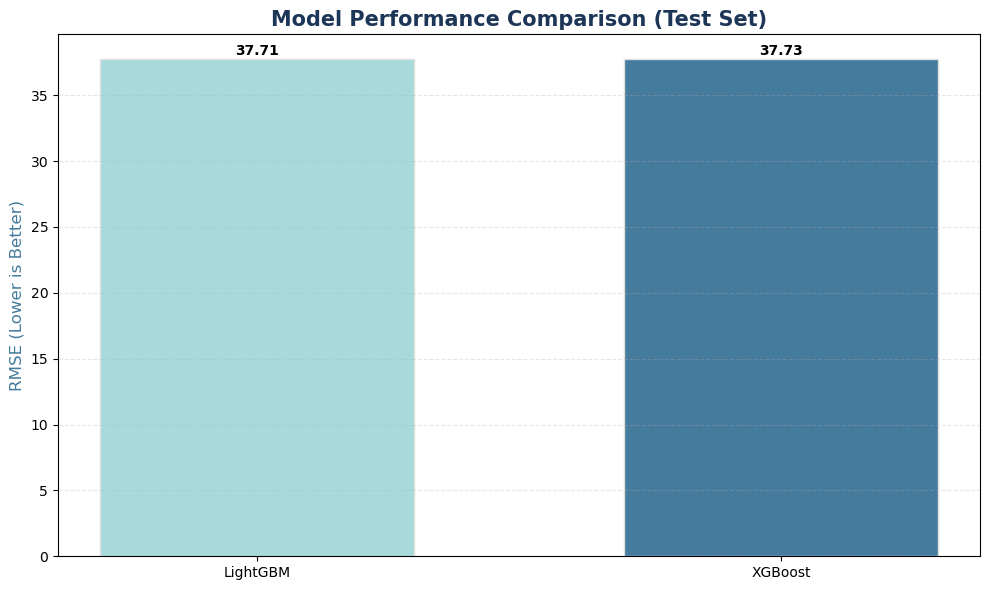

In [28]:
results = {
    'XGBoost': np.sqrt(mean_squared_error(y_test, xgb_preds)),
    'LightGBM': np.sqrt(mean_squared_error(y_test, lgb_preds))
}

# Sort results best to worst (Lower RMSE is better)
sorted_res = dict(sorted(results.items(), key=lambda item: item[1]))

# Visualization
plt.figure(figsize=(10, 6), facecolor='white')
colors = ['#A8DADC', '#457B9D'] # Milky blue/slate palette

bars = plt.bar(sorted_res.keys(), sorted_res.values(), color=colors, edgecolor='#E0E0E0', width=0.6)
plt.title('Model Performance Comparison (Test Set)', fontsize=15, fontweight='bold', color='#1D3557')
plt.ylabel('RMSE (Lower is Better)', fontsize=12, color='#457B9D')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [35]:
df['date']

0        2013-01-01
1        2013-01-02
2        2013-01-03
3        2013-01-04
4        2013-01-05
            ...    
912995   2017-12-27
912996   2017-12-28
912997   2017-12-29
912998   2017-12-30
912999   2017-12-31
Name: date, Length: 913000, dtype: datetime64[ns]

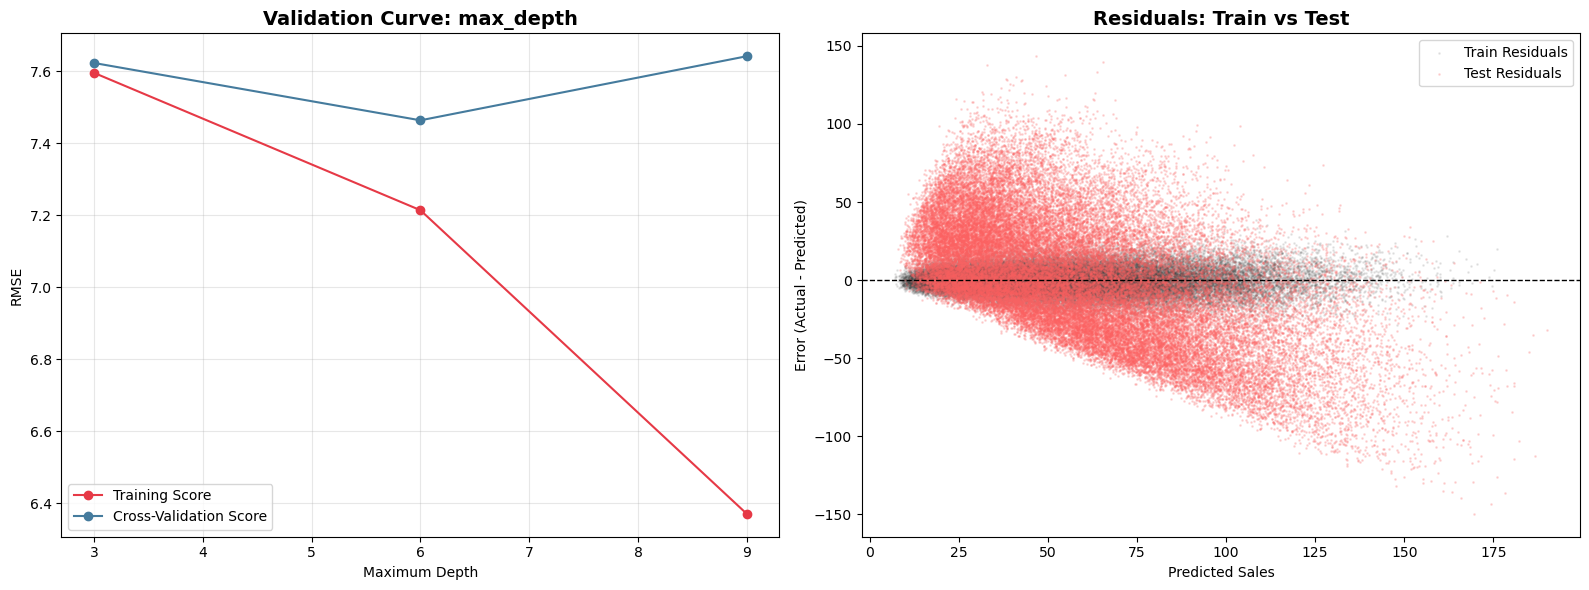

In [33]:
from sklearn.model_selection import validation_curve

# 1. Validation Curve (Testing max_depth - a "famous" tuning parameter)
# We limit the range and CV folds to keep it under 5 mins
param_range = [3, 6, 9]
train_scores, test_scores = validation_curve(
    xgb.XGBRegressor(tree_method='hist', n_estimators=100), # Lower estimators for speed
    x_train, y_train, 
    param_name="max_depth", 
    param_range=param_range,
    cv=3, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1
)

# Convert back to positive RMSE
train_rmse = -np.mean(train_scores, axis=1)
test_rmse = -np.mean(test_scores, axis=1)

# 2. Residual Calculation
train_preds = xgb_model.predict(x_train)
test_preds = xgb_model.predict(x_test)

train_residuals = y_train - train_preds
test_residuals = y_test - test_preds

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Validation Curve
ax1.plot(param_range, train_rmse, label="Training Score", color='#E63946', marker='o')
ax1.plot(param_range, test_rmse, label="Cross-Validation Score", color='#457B9D', marker='o')
ax1.set_title("Validation Curve: max_depth", fontsize=14, fontweight='bold')
ax1.set_xlabel("Maximum Depth")
ax1.set_ylabel("RMSE")
ax1.grid(alpha=0.3)
ax1.legend()

# Subplot 2: Residuals
# Sampling 50k points for the plot to avoid PC lag while maintaining the distribution
sample_idx_train = np.random.choice(len(train_residuals), 50000, replace=False)
sample_idx_test = np.random.choice(len(test_residuals), 50000, replace=False)

ax2.scatter(train_preds[sample_idx_train], train_residuals.iloc[sample_idx_train], 
            alpha=0.1, color="#494A49", label='Train Residuals', s=1)
ax2.scatter(test_preds[sample_idx_test], test_residuals.iloc[sample_idx_test], 
            alpha=0.2, color="#FB6262", label='Test Residuals', s=1)

ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("Residuals: Train vs Test", fontsize=14, fontweight='bold')
ax2.set_xlabel("Predicted Sales")
ax2.set_ylabel("Error (Actual - Predicted)")
ax2.legend()

plt.tight_layout()
plt.show()

In [36]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Physical Split
train_df = df[df['date'] < '2017-01-01'].copy()
test_df = df[df['date'] >= '2017-01-01'].copy()

# 2. Separate Target
y_train = train_df['sales'].copy()
y_test = test_df['sales'].copy()

# 3. CV Format for Step 3
# Using 3 splits to keep the computation fast (< 5 mins)
tscv = TimeSeriesSplit(n_splits=3)

In [37]:
import xgboost as xgb

# Minimalist but wide-ranging space
param_dist = {
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__n_estimators': [100] # Kept low for speed
}

# Initialize XGBoost with Hist-based method for 1M rows
xgb_reg = xgb.XGBRegressor(
    tree_method='hist',
    device="cpu", # Change to "cuda" if you have a GPU
    random_state=42,
    n_jobs=-1
)

In [38]:
from sklearn.model_selection import RandomizedSearchCV

# Update: Custom drop logic inside the pipeline-compatible class
class PipelineFeatureEngineer(TimeSeriesFeatureEngineer):
    def transform(self, X):
        X_out = super().transform(X)
        # DROP sales and date so the regressor doesn't see the answer
        return X_out.drop(columns=['sales', 'date'], errors='ignore')

# Create the Pipeline
model_pipeline = Pipeline([
    ('engineer', PipelineFeatureEngineer()),
    ('regressor', xgb_reg)
])

# Initialize Randomized Search
search = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_dist,
    n_iter=5, # 5 random combinations
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

# Fit the search
# We pass the full train_df because the engineer needs the 'sales' column internally
search.fit(train_df, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'regressor__learning_rate': [0.05, 0.1], 'regressor__max_depth': [3, 5, ...], 'regressor__n_estimators': [100], 'regressor__subsample': [0.8, 1.0]}"
,n_iter,5
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


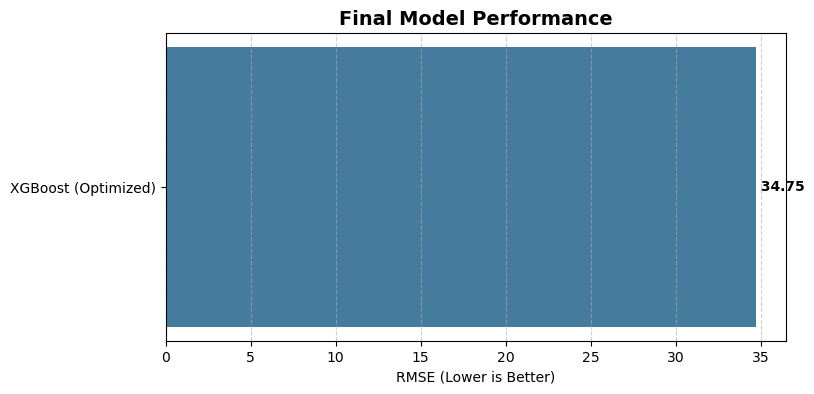

In [39]:
from sklearn.metrics import mean_squared_error

# 1. Prepare Test Data with "Warm-Start" History
# Combine last year of train with test to populate lags/rolling windows
warm_start_df = pd.concat([train_df.tail(365 * 50), test_df]) # 50 items/stores approx
best_model = search.best_estimator_

# 2. Predict
# The pipeline handles the transformation and dropping of sales/date
all_preds = best_model.predict(warm_start_df)
test_preds = all_preds[-len(test_df):] # Extract only the 2017 predictions

# 3. Calculate RMSE
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

# 4. HBar Plot
plt.figure(figsize=(8, 4))
plt.barh(['XGBoost (Optimized)'], [test_rmse], color='#457B9D', height=0.5)
plt.title('Final Model Performance', fontsize=14, fontweight='bold')
plt.xlabel('RMSE (Lower is Better)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.text(test_rmse, 0, f' {test_rmse:.2f}', va='center', fontweight='bold')
plt.show()

In [40]:
import plotly.express as px

# Extract results
cv_results = pd.DataFrame(search.cv_results_)

# Clean column names for plotting
plot_df = cv_results[[
    'param_regressor__max_depth', 
    'param_regressor__learning_rate', 
    'param_regressor__subsample', 
    'mean_test_score'
]].copy()

plot_df['RMSE'] = -plot_df['mean_test_score']
plot_df.columns = ['Max Depth', 'Learning Rate', 'Subsample', 'Score', 'RMSE']

# Plot
fig = px.parallel_coordinates(
    plot_df,
    color="RMSE",
    labels={"RMSE": "RMSE Score"},
    color_continuous_scale=px.colors.sequential.Viridis_r,
    title="XGBoost Hyperparameter Coordinate Map"
)
fig.show()

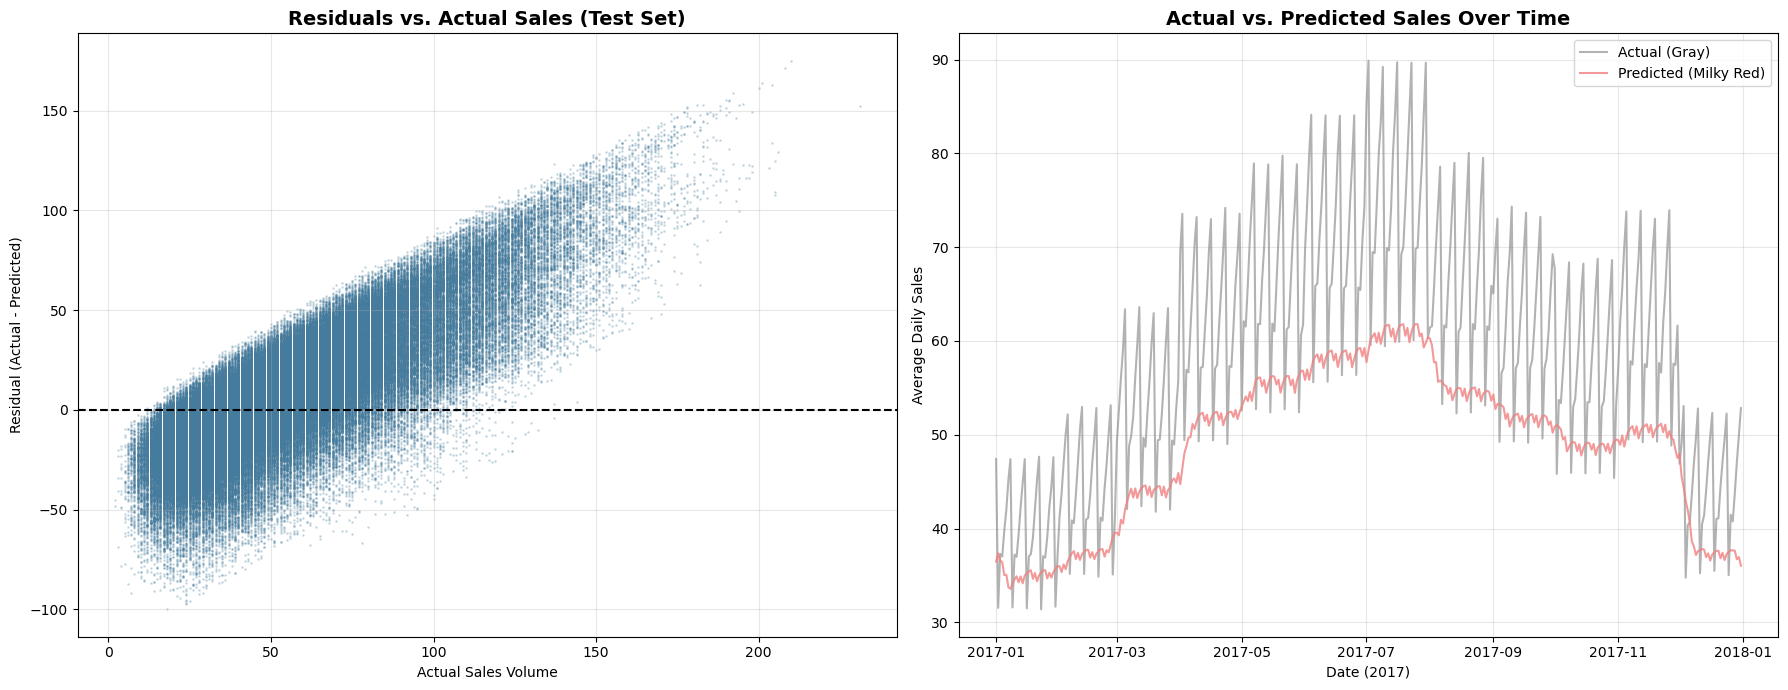

In [41]:
import matplotlib.pyplot as plt

# 1. Calculate Residuals for the Test Set
test_residuals = y_test - test_preds

# 2. Setup Plot (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# --- Subplot 1: Residuals vs. Actual Sales (Checking for Structural Bias) ---
ax1.scatter(y_test, test_residuals, alpha=0.2, color='#457B9D', s=1)
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.set_title("Residuals vs. Actual Sales (Test Set)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Actual Sales Volume")
ax1.set_ylabel("Residual (Actual - Predicted)")
ax1.grid(alpha=0.3)

# --- Subplot 2: Actual vs. Predicted over Time ---
# We sample a specific store/item for clarity, or plot the mean sales across all
# Let's plot the mean daily sales to see the general trend
test_dates = test_df['date']
daily_actual = pd.DataFrame({'date': test_dates, 'sales': y_test}).groupby('date')['sales'].mean()
daily_pred = pd.DataFrame({'date': test_dates, 'sales': test_preds}).groupby('date')['sales'].mean()

ax2.plot(daily_actual.index, daily_actual.values, color='#808080', alpha=0.6, label='Actual (Gray)', linewidth=1.5)
ax2.plot(daily_pred.index, daily_pred.values, color='#F08080', alpha=0.8, label='Predicted (Milky Red)', linewidth=1.5)

ax2.set_title("Actual vs. Predicted Sales Over Time", fontsize=14, fontweight='bold')
ax2.set_xlabel("Date (2017)")
ax2.set_ylabel("Average Daily Sales")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Using log transform

In [42]:
from sklearn.model_selection import TimeSeriesSplit

# Chronological split
train_df = df[df['date'] < '2017-01-01'].copy()
test_df = df[df['date'] >= '2017-01-01'].copy()

y_train = train_df['sales'].copy()
y_test = test_df['sales'].copy()

tscv = TimeSeriesSplit(n_splits=3)

In [43]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Define the base XGBoost model
xgb_reg = xgb.XGBRegressor(tree_method='hist', random_state=42, n_jobs=-1)

# 2. Wrap it in a Log-Transformer
# This handles the 0s by using log(1+x)
log_regressor = TransformedTargetRegressor(
    regressor=xgb_reg,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. Complete Pipeline
model_pipeline = Pipeline([
    ('engineer', PipelineFeatureEngineer()), # From our previous code
    ('regressor', log_regressor)
])

# 4. Search Space (Adjusted for log-transformed targets)
param_dist = {
    'regressor__regressor__max_depth': [4, 6, 8],
    'regressor__regressor__learning_rate': [0.05, 0.1],
    'regressor__regressor__n_estimators': [100]
}

search = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)

search.fit(train_df, y_train)

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning:

One or more of the test scores are non-finite: [nan nan nan nan nan]



,estimator,"Pipeline(step...None, ...)))])"
,param_distributions,"{'regressor__regressor__learning_rate': [0.05, 0.1], 'regressor__regressor__max_depth': [4, 6, ...], 'regressor__regressor__n_estimators': [100]}"
,n_iter,5
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


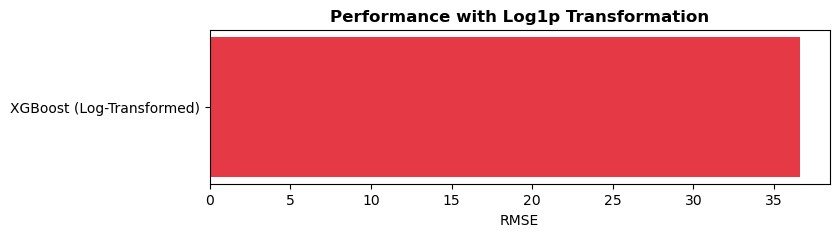

In [44]:
# Prepare test data with history for warm-start
warm_start_df = pd.concat([train_df.tail(365 * 50), test_df])
test_preds = search.best_estimator_.predict(warm_start_df)[-len(test_df):]

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

plt.figure(figsize=(8, 2))
plt.barh(['XGBoost (Log-Transformed)'], [test_rmse], color='#E63946')
plt.title('Performance with Log1p Transformation', fontweight='bold')
plt.xlabel('RMSE')
plt.show()

In [45]:
import plotly.express as px

cv_results = pd.DataFrame(search.cv_results_)
plot_df = cv_results[['param_regressor__regressor__max_depth', 
                      'param_regressor__regressor__learning_rate', 
                      'mean_test_score']].copy()
plot_df['RMSE'] = -plot_df['mean_test_score']

fig = px.parallel_coordinates(plot_df, color="RMSE", color_continuous_scale=px.colors.sequential.Viridis_r)
fig.show()

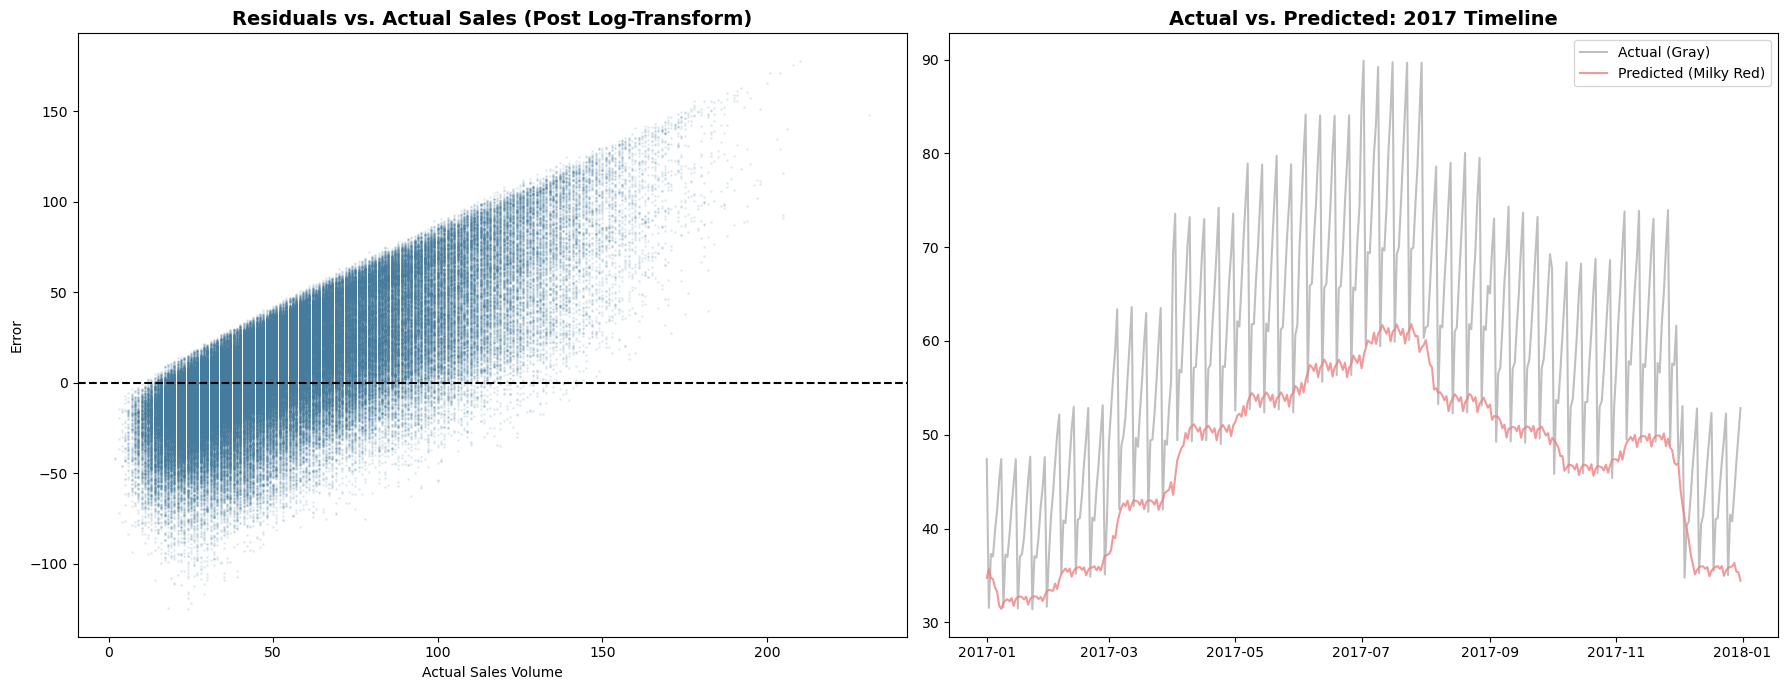

In [46]:
test_residuals = y_test - test_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Subplot 1: Residuals vs. Actual Sales (Checking for Homoscedasticity)
ax1.scatter(y_test, test_residuals, alpha=0.1, color='#457B9D', s=1)
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.set_title("Residuals vs. Actual Sales (Post Log-Transform)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Actual Sales Volume")
ax1.set_ylabel("Error")

# Subplot 2: Actual vs. Predicted Time Series
daily_actual = pd.DataFrame({'date': test_df['date'], 'sales': y_test}).groupby('date')['sales'].mean()
daily_pred = pd.DataFrame({'date': test_df['date'], 'sales': test_preds}).groupby('date')['sales'].mean()

ax2.plot(daily_actual.index, daily_actual.values, color='#808080', alpha=0.5, label='Actual (Gray)')
ax2.plot(daily_pred.index, daily_pred.values, color='#F08080', alpha=0.8, label='Predicted (Milky Red)')
ax2.set_title("Actual vs. Predicted: 2017 Timeline", fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

### Forecasting

In [30]:
# sales / volatility

### Business Questions

##### item_level: ordering specific stock

In [51]:
import pandas as pd
import numpy as np

# 1. Define a focused Horizon: January 2018 Only
jan_2018_dates = pd.date_range(start='2018-01-01', end='2018-01-31')

# Create the grid for all stores and items
stores = train_df['store'].unique()
items = train_df['item'].unique()

jan_grid = pd.MultiIndex.from_product(
    [jan_2018_dates, stores, items], 
    names=['date', 'store', 'item']
).to_frame(index=False)

# 2. Warm-Start: Provide 2017 data as context for the features
# The model needs 2017 to calculate the 'lag_365' and 'roll_mean_365' for Jan 2018
history_for_features = test_df.copy() # All of 2017
jan_input = pd.concat([history_for_features, jan_grid], axis=0).sort_values(['store', 'item', 'date'])

# 3. Generate Predictions
# The pipeline automatically handles the log-inverse (expm1) back to real sales
all_preds = search.best_estimator_.predict(jan_input)
jan_grid['predicted_sales'] = all_preds[-len(jan_grid):]

# 4. Apply the Safety Buffer (2.0 Standard Deviation of residuals)
error_std = np.std(y_test - test_preds)
jan_grid['safe_order_level'] = jan_grid['predicted_sales'] + (2 * error_std)

# 5. Summarize for the Inventory Manager
jan_summary = jan_grid.groupby(['store', 'item'])[['predicted_sales', 'safe_order_level']].sum().reset_index()

In [53]:
# Extract 2017 Actuals
# We use .dt.year to access the year component of the datetime objects
actual_2017 = df[df['date'].dt.year == 2017].groupby(['store', 'item'])['sales'].sum().reset_index()
actual_2017.columns = ['store', 'item', 'actual_sales_2017']

# Merge with your 2018 Forecast for a side-by-side comparison
comparison = pd.merge(jan_summary, actual_2017, on=['store', 'item'])
comparison['diff_pct'] = ((comparison['predicted_sales'] - comparison['actual_sales_2017']) / comparison['actual_sales_2017']) * 100

print("Comparison: Jan 2018 Forecast vs. 2017 Full Year Actuals")
print(comparison.head())

Comparison: Jan 2018 Forecast vs. 2017 Full Year Actuals
   store  item  predicted_sales  safe_order_level  actual_sales_2017  \
0      1     1      1086.646729       3246.002686               8097   
1      1     2      1083.886108       3243.242188              21823   
2      1     3      1080.620361       3239.976318              13646   
3      1     4      1092.972412       3252.328613               8078   
4      1     5      1098.722778       3258.078857               6824   

    diff_pct  
0 -86.579638  
1 -95.033285  
2 -92.081047  
3 -86.469765  
4 -83.899139  


**critical stockout flag**

In [ ]:
# 1. Calculate Historical Jan Max for each store/item
jan_history = train_df[train_df['date'].dt.month == 1]
historical_max = jan_history.groupby(['store', 'item'])['sales'].max().reset_index()
historical_max.columns = ['store', 'item', 'hist_jan_max']

# 2. Merge with our 2018 January Forecast
alerts = pd.merge(jan_summary, historical_max, on=['store', 'item'])

# 3. Calculate Risk Score: How much higher is our safe order than previous peaks?
alerts['risk_factor'] = (alerts['safe_order_level'] / alerts['hist_jan_max'])
critical_stockouts = alerts[alerts['risk_factor'] > 1.15].sort_values('risk_factor', ascending=False)

# 4. Format for Executives (Top 5)
executive_view = critical_stockouts.head(5).copy()
executive_view['Status'] = '🔴 CRITICAL RISK'
executive_view = executive_view[['store', 'item', 'predicted_sales', 'safe_order_level', 'hist_jan_max', 'Status']]
executive_view.columns = ['Store ID', 'Item ID', 'Expected Sales', 'Rec. Order (Buffer)', 'Prev. Peak', 'Alert Status']

In [55]:
executive_view

,Store ID,Item ID,Expected Sales,Rec. Order (Buffer),Prev. Peak,Alert Status
254,6,5,1063.829468,3223.185547,16,🔴 CRITICAL RISK
204,5,5,1085.691528,3245.047607,18,🔴 CRITICAL RISK
340,7,41,1086.752075,3246.108154,19,🔴 CRITICAL RISK
276,6,27,1067.524780,3226.880859,19,🔴 CRITICAL RISK
226,5,27,1087.642090,3246.998047,20,🔴 CRITICAL RISK


In [58]:
# 1. Aggregate daily sales per store
store_daily_sales = jan_grid.groupby(['date', 'store'])['predicted_sales'].sum().reset_index()

# 2. Determine "High Volume" threshold (Top 15% of days)
threshold = store_daily_sales['predicted_sales'].quantile(0.85)
staffing_alerts = store_daily_sales[store_daily_sales['predicted_sales'] > threshold].copy()

# 3. Format for Executive readability
staffing_alerts['Day'] = staffing_alerts['date'].dt.day_name()
staffing_alerts['Staffing Level'] = '⬆️ HIGH (Extra Shifts Needed)'
staffing_dashboard = staffing_alerts.sort_values(by=['date', 'store']) # Show first 10 alerts

In [59]:
staffing_dashboard

,date,store,predicted_sales,Day,Staffing Level
82,2018-01-09,3,3036.138672,Tuesday,⬆️ HIGH (Extra Shifts Needed)
83,2018-01-09,4,3339.898438,Tuesday,⬆️ HIGH (Extra Shifts Needed)
84,2018-01-09,5,3474.732910,Tuesday,⬆️ HIGH (Extra Shifts Needed)
85,2018-01-09,6,2994.859863,Tuesday,⬆️ HIGH (Extra Shifts Needed)
91,2018-01-10,2,3021.449219,Wednesday,⬆️ HIGH (Extra Shifts Needed)
92,2018-01-10,3,3011.976562,Wednesday,⬆️ HIGH (Extra Shifts Needed)
99,2018-01-10,10,2899.640381,Wednesday,⬆️ HIGH (Extra Shifts Needed)
100,2018-01-11,1,2886.494385,Thursday,⬆️ HIGH (Extra Shifts Needed)
130,2018-01-14,1,2856.516113,Sunday,⬆️ HIGH (Extra Shifts Needed)
131,2018-01-14,2,3217.365479,Sunday,⬆️ HIGH (Extra Shifts Needed)
